# Relax Data Challenge

  A   usage   summary   table   ( "takehome_user_engagement" )   that   has   a   row   for   each   day 
that   a   user   logged   into   the   product.  
Defining   an    "adopted   user"    as   a   user   who     has   logged   into   the   product   on   three   separate 
days   in   at   least   one   sevenday   period ,   identify   which   factors   predict   future   user 
adoption .

answer - The biggest factor predicting user adoption is the organization size. This may be a due to other family members/friends already being a part of this organization and so they want to be there too, but its hard to say. The models are not the greatest as the accuracy is only 56% with a recall for the adopted users being 50%. More data would help with this, but it is a start and can give an idea of what allows for an increase in adopted users.

In [1]:
 # First need to load the relevant libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# now need to import the data

df_engage = pd.read_csv(r"C:\Users\benpe\OneDrive\Documents\GitHub\Projects\1481069814_relax_challenge\relax_challenge\takehome_user_engagement.csv")
df_user = pd.read_csv(r"C:\Users\benpe\OneDrive\Documents\GitHub\Projects\1481069814_relax_challenge\relax_challenge\takehome_users.csv", encoding='latin-1')


In [3]:
df_engage.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


In [4]:
df_engage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   time_stamp  207917 non-null  object
 1   user_id     207917 non-null  int64 
 2   visited     207917 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.8+ MB


In [5]:
df_engage.describe()

,user_id,visited
count,207917.000000,207917.0
mean,5913.314197,1.0
std,3394.941674,0.0
min,1.000000,1.0
25%,3087.000000,1.0
50%,5682.000000,1.0
75%,8944.000000,1.0
max,12000.000000,1.0


In [6]:
df_engage.isnull().sum()

time_stamp    0
user_id       0
visited       0
dtype: int64

In [7]:
print(f"Duplicate rows in df_engage: {df_engage.duplicated().sum()}")

duplicate_logins = df_engage.duplicated(subset=['user_id', 'time_stamp']).sum()
print(f"Duplicate user-timestamp pairs: {duplicate_logins}")

Duplicate rows in df_engage: 0
Duplicate user-timestamp pairs: 0


In [8]:
df_user.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


In [9]:
df_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   object_id                   12000 non-null  int64  
 1   creation_time               12000 non-null  object 
 2   name                        12000 non-null  object 
 3   email                       12000 non-null  object 
 4   creation_source             12000 non-null  object 
 5   last_session_creation_time  8823 non-null   float64
 6   opted_in_to_mailing_list    12000 non-null  int64  
 7   enabled_for_marketing_drip  12000 non-null  int64  
 8   org_id                      12000 non-null  int64  
 9   invited_by_user_id          6417 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 937.6+ KB


In [10]:
df_user.describe()

,object_id,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
count,12000.00000,8.823000e+03,12000.000000,12000.000000,12000.000000,6417.000000
mean,6000.50000,1.379279e+09,0.249500,0.149333,141.884583,5962.957145
std,3464.24595,1.953116e+07,0.432742,0.356432,124.056723,3383.761968
min,1.00000,1.338452e+09,0.000000,0.000000,0.000000,3.000000
25%,3000.75000,1.363195e+09,0.000000,0.000000,29.000000,3058.000000
50%,6000.50000,1.382888e+09,0.000000,0.000000,108.000000,5954.000000
75%,9000.25000,1.398443e+09,0.000000,0.000000,238.250000,8817.000000
max,12000.00000,1.402067e+09,1.000000,1.000000,416.000000,11999.000000


In [11]:
df_user.isnull().sum()

object_id                        0
creation_time                    0
name                             0
email                            0
creation_source                  0
last_session_creation_time    3177
opted_in_to_mailing_list         0
enabled_for_marketing_drip       0
org_id                           0
invited_by_user_id            5583
dtype: int64

In [12]:
print(f"Duplicate rows in df_user: {df_user.duplicated().sum()}")

print(f"Duplicate object_ids: {df_user['object_id'].duplicated().sum()}")

print(f"Duplicate emails: {df_user['email'].duplicated().sum()}")

Duplicate rows in df_user: 0
Duplicate object_ids: 0
Duplicate emails: 20


Plan of attach is as follows:

1. use df_engage to determine is a specific user id has logged on 3 days within any 7 day period (def of adopted user)
2. Join df_engage and df_user using object_id and user_id columns
3. use Random Forest to determine important features

In [13]:
# First for the adopted user designation

df_engage['time_stamp'] = pd.to_datetime(df_engage['time_stamp'])
df_engage['date'] = df_engage['time_stamp'].dt.date
df_engage.sort_values(['user_id','date'], ascending=True)
df_engage.head()

,time_stamp,user_id,visited,date
0,2014-04-22 03:53:30,1,1,2014-04-22
1,2013-11-15 03:45:04,2,1,2013-11-15
2,2013-11-29 03:45:04,2,1,2013-11-29
3,2013-12-09 03:45:04,2,1,2013-12-09
4,2013-12-25 03:45:04,2,1,2013-12-25


In [14]:

adopted_users = []

# 3. Group by user and loop
for user_id, group in df_engage.groupby('user_id'):
    # We only care if they have at least 3 logins
    if len(group) >= 3:
        # Convert the dates to a list for easy indexing
        login_dates = list(group['date'])
        
        # Look at every window of 3 logins
        # (i) is the 1st login, (i+2) is the 3rd login
        for i in range(len(login_dates) - 2):
            delta = login_dates[i+2] - login_dates[i]
            
            if delta.days <= 7:
                adopted_users.append(user_id)
                break # We found they are adopted, no need to check further for this user

print(f"Total Adopted Users identified: {len(adopted_users)}")

Total Adopted Users identified: 1656


In [15]:
# Create the binary target column
df_user['adopted'] = df_user['object_id'].isin(adopted_users).astype(int)

# Check how many adopted vs non-adopted you have
print(df_user['adopted'].value_counts())

adopted
0    10344
1     1656
Name: count, dtype: int64


In [16]:
df_user.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0,0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0,1
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0,0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0,0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0,0


In [17]:
df_user.isnull().sum()

object_id                        0
creation_time                    0
name                             0
email                            0
creation_source                  0
last_session_creation_time    3177
opted_in_to_mailing_list         0
enabled_for_marketing_drip       0
org_id                           0
invited_by_user_id            5583
adopted                          0
dtype: int64

In [18]:
# my guess is that if the invited by user id is null, then it is actually null

df_user['invited_by_user_id'].fillna('None', inplace = True)
df_user.isnull().sum()

C:\Users\benpe\AppData\Local\Temp\ipykernel_29728\2470642882.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_user['invited_by_user_id'].fillna('None', inplace = True)
C:\Users\benpe\AppData\Local\Temp\ipykernel_29728\2470642882.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'None' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_user['invited_by_user_id'].fillna('None', inplace = True)


object_id                        0
creation_time                    0
name                             0
email                            0
creation_source                  0
last_session_creation_time    3177
opted_in_to_mailing_list         0
enabled_for_marketing_drip       0
org_id                           0
invited_by_user_id               0
adopted                          0
dtype: int64

In [19]:
# Assuming last session creation time means they never logged in. this column should be dropped as t is adding in an extra date that may confuse the model

df_user = df_user.drop(columns='last_session_creation_time')
df_user.head()

,object_id,creation_time,name,email,creation_source,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1,0,11,10803.0,0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,0,0,1,316.0,1
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,0,0,94,1525.0,0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,0,0,1,5151.0,0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,0,0,193,5240.0,0


In [20]:
# Also going to get rid of creation time

df_user = df_user.drop(columns='creation_time')
df_user.head()

,object_id,name,email,creation_source,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted
0,1,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1,0,11,10803.0,0
1,2,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,0,0,1,316.0,1
2,3,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,0,0,94,1525.0,0
3,4,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,0,0,1,5151.0,0
4,5,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,0,0,193,5240.0,0


In [21]:
# These likely do not contribute to future behavior

df_user = df_user.drop(columns=['object_id','name', 'email', 'invited_by_user_id'])
df_user.head()

,creation_source,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,adopted
0,GUEST_INVITE,1,0,11,0
1,ORG_INVITE,0,0,1,1
2,ORG_INVITE,0,0,94,0
3,GUEST_INVITE,0,0,1,0
4,GUEST_INVITE,0,0,193,0


In [22]:
org_counts = df_user['org_id'].value_counts()
df_user['org_size'] = df_user['org_id'].map(org_counts)

# 2. One-hot encode creation_source
# This will create columns like creation_source_PERSONAL_PROJECTS, etc.
df_encoded = pd.get_dummies(df_user, columns=['creation_source'], drop_first=True)

df_encoded.head()

,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,adopted,org_size,creation_source_ORG_INVITE,creation_source_PERSONAL_PROJECTS,creation_source_SIGNUP,creation_source_SIGNUP_GOOGLE_AUTH
0,1,0,11,0,75,False,False,False,False
1,0,0,1,1,233,True,False,False,False
2,0,0,94,0,32,True,False,False,False
3,0,0,1,0,233,False,False,False,False
4,0,0,193,0,16,False,False,False,False


In [24]:
df_encoded = df_encoded.drop(columns='org_id')
df_encoded.head()

,opted_in_to_mailing_list,enabled_for_marketing_drip,adopted,org_size,creation_source_ORG_INVITE,creation_source_PERSONAL_PROJECTS,creation_source_SIGNUP,creation_source_SIGNUP_GOOGLE_AUTH
0,1,0,0,75,False,False,False,False
1,0,0,1,233,True,False,False,False
2,0,0,0,32,True,False,False,False
3,0,0,0,233,False,False,False,False
4,0,0,0,16,False,False,False,False


In [30]:
X = df_encoded[['opted_in_to_mailing_list', 
                     'enabled_for_marketing_drip', 
                     'org_size', 
                     'creation_source_ORG_INVITE', 
                     'creation_source_PERSONAL_PROJECTS', 
                     'creation_source_SIGNUP', 
                     'creation_source_SIGNUP_GOOGLE_AUTH']]
y = df_encoded['adopted']

y.head()

0    0
1    1
2    0
3    0
4    0
Name: adopted, dtype: int64

In [32]:
X = X.astype(int)
X.head()

,opted_in_to_mailing_list,enabled_for_marketing_drip,org_size,creation_source_ORG_INVITE,creation_source_PERSONAL_PROJECTS,creation_source_SIGNUP,creation_source_SIGNUP_GOOGLE_AUTH
0,1,0,75,0,0,0,0
1,0,0,233,1,0,0,0
2,0,0,32,1,0,0,0
3,0,0,233,0,0,0,0
4,0,0,16,0,0,0,0


In [34]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Define the parameter grid
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

# 3. Initialize the model and the search
rf = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, 
                                   n_iter=20, cv=5, scoring='f1', 
                                   random_state=42, n_jobs=-1)

# 4. Fit the search
random_search.fit(X_train, y_train)

# 5. Get the best results
best_rf = random_search.best_estimator_
print(f"Best Parameters: {random_search.best_params_}")

Best Parameters: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10, 'class_weight': 'balanced'}


In [38]:
final_rf = RandomForestClassifier(
    n_estimators=random_search.best_params_['n_estimators'],
    max_depth=random_search.best_params_['max_depth'],
    min_samples_split=random_search.best_params_['min_samples_split'],
    min_samples_leaf=random_search.best_params_['min_samples_leaf'],
    class_weight='balanced_subsample',
    random_state=42
)

final_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=10,
                       min_samples_leaf=2, min_samples_split=10,
                       n_estimators=50, random_state=42)

Overall Model Accuracy: 0.56

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.58      0.70      2069
           1       0.16      0.50      0.24       331

    accuracy                           0.56      2400
   macro avg       0.52      0.54      0.47      2400
weighted avg       0.78      0.56      0.63      2400



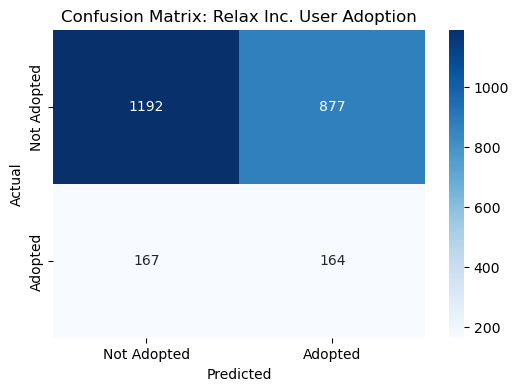

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
y_pred = final_rf.predict(X_test)

# 1. Print Accuracy
print(f"Overall Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")

# 2. Detailed Classification Report
# This shows Precision, Recall, and F1 for BOTH classes
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 3. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Adopted', 'Adopted'], 
            yticklabels=['Not Adopted', 'Adopted'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: Relax Inc. User Adoption')
plt.show()

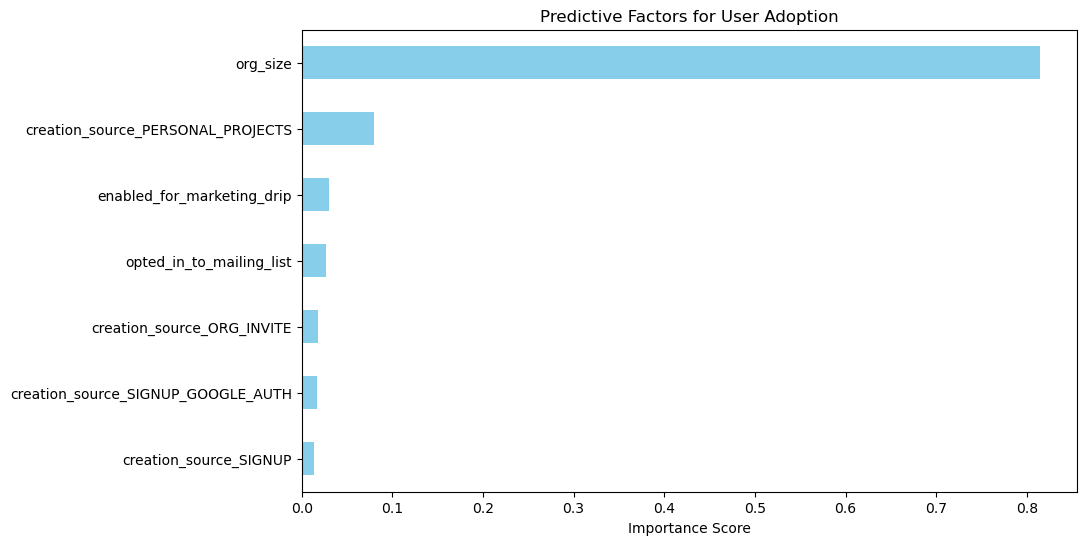

org_size                              0.814213
creation_source_PERSONAL_PROJECTS     0.079576
enabled_for_marketing_drip            0.030531
opted_in_to_mailing_list              0.026974
creation_source_ORG_INVITE            0.017878
creation_source_SIGNUP_GOOGLE_AUTH    0.016962
creation_source_SIGNUP                0.013866
dtype: float64


In [40]:
importances = pd.Series(final_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='skyblue')
plt.title('Predictive Factors for User Adoption')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

print(importances)